In [6]:
from serial.tools import list_ports
from lib.new_drivers import Bilancia
from matplotlib import pyplot as plt
import ipywidgets as widgets
from collections import deque
import ipywidgets as widgets
from matplotlib import pyplot as plt

In [7]:
%matplotlib widget
plt.close('all')

In [8]:
ports = list_ports.comports()

choose_port = widgets.Dropdown(
    options=[(port.device, port.device) for port in ports],
    description='Porta:',
)
display(choose_port)

Dropdown(description='Porta:', options=(('/dev/ttyS31', '/dev/ttyS31'), ('/dev/ttyS30', '/dev/ttyS30'), ('/dev…

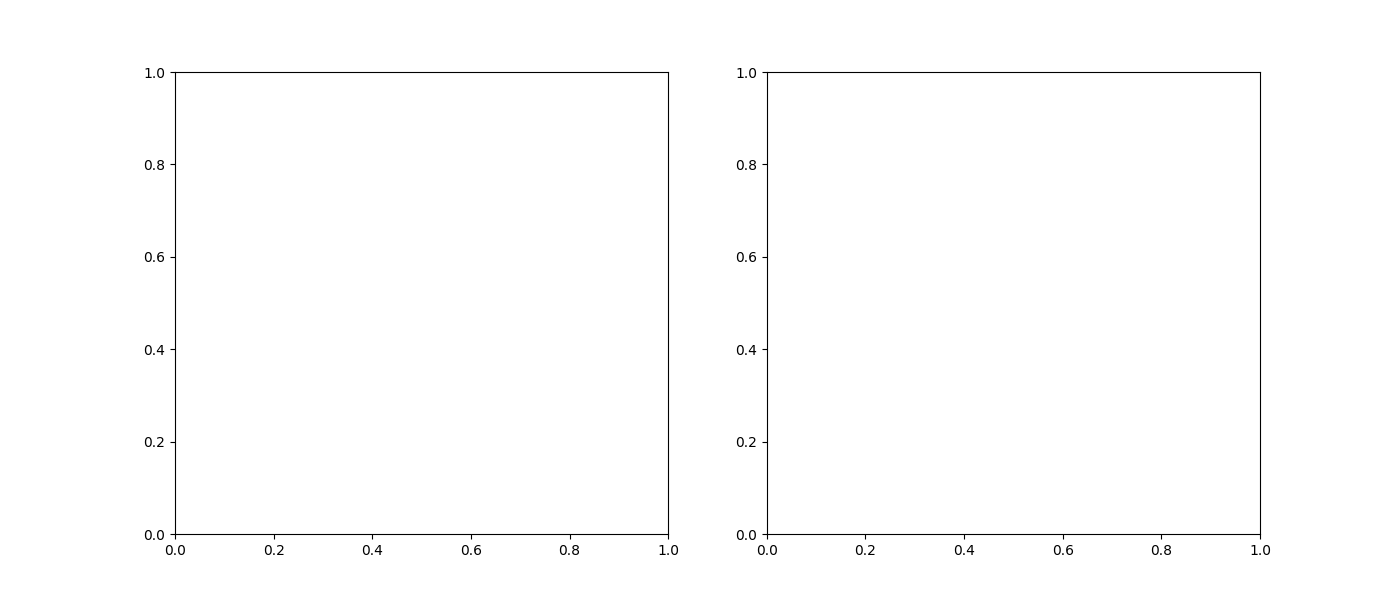

Button(description='Start', style=ButtonStyle())

Button(description='Stop', disabled=True, style=ButtonStyle())

In [10]:


spessori = deque(maxlen=100)
rate = deque(maxlen=100)
timestamps = deque(maxlen=100)

Running = False
plot_timer = None

with plt.ioff():
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    display(fig.canvas)

    spessore_line, = axs[0].plot([], [], label="Spessori", marker="o")
    rate_line, = axs[1].plot([], [], label="Rate", marker="o")

    axs[0].set_title("Spessori")
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Spessore")
    axs[0].grid()

    axs[1].set_title("Rate")
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Rate")
    axs[1].grid()

bilancia = Bilancia(choose_port.value)

stop_btn = widgets.Button(description="Stop", disabled=True)
start_btn = widgets.Button(description="Start", disabled=False)
display(start_btn, stop_btn)

def reset_plot():
    spessori.clear()
    rate.clear()
    timestamps.clear()
    spessore_line.set_data([], [])
    rate_line.set_data([], [])
    fig.canvas.draw_idle()

def _safe_ylim(values):
    if not values:
        return (0, 1)
    vmax = max(values)
    if vmax <= 0:
        return (0, 1)
    return (0, vmax * 1.2)

def update_plot_once():
    t = bilancia.get_latest_data()
    if t is None:
        return

    try:
        (spessore, r), timestamp = t
        spessore = float(spessore)
        r = float(r)
        timestamp = float(timestamp)
    except (TypeError, ValueError):
        # Scarta campione corrotto, non uccidere l'update loop
        print("Dati corrotti ricevuti, scartando campione")
        return

    spessori.append(spessore)
    rate.append(r)
    timestamps.append(timestamp)

    if len(timestamps) > 100:
        timestamps.popleft()
        spessori.popleft()
        rate.popleft()

    x = list(timestamps)
    y1 = list(spessori)
    y2 = list(rate)

    spessore_line.set_data(x, y1)
    rate_line.set_data(x, y2)

    if len(x) == 1:
        axs[0].set_xlim(x[0] - 1, x[0] + 1)
        axs[1].set_xlim(x[0] - 1, x[0] + 1)
    else:
        axs[0].set_xlim(min(x), max(x))
        axs[1].set_xlim(min(x), max(x))

    axs[0].set_ylim(*_safe_ylim(y1))
    axs[1].set_ylim(*_safe_ylim(y2))

    fig.canvas.draw_idle()

def on_start_btn_click(b):
    global Running, plot_timer
    if Running:
        return

    reset_plot()
    bilancia.start_continuous_read()

    plot_timer = fig.canvas.new_timer(interval=100)
    plot_timer.add_callback(update_plot_once)
    plot_timer.start()

    Running = True
    start_btn.disabled = True
    stop_btn.disabled = False

def on_stop_btn_click(b):
    global Running, plot_timer
    if not Running:
        return

    Running = False

    if plot_timer is not None:
        plot_timer.stop()
        plot_timer = None

    bilancia.stop_continuous_read()
    start_btn.disabled = False
    stop_btn.disabled = True

def on_close(evt):
    # Chiusura pulita se chiudi la figura
    if Running:
        on_stop_btn_click(None)

fig.canvas.mpl_connect("close_event", on_close)

start_btn.on_click(on_start_btn_click)
stop_btn.on_click(on_stop_btn_click)